# Siamese Neural Networks for One-Shot Image Recognition

## Project Introduction:

This project reproduces and explores the Siamese Neural Network model presented in the paper “Siamese Neural Networks for One-shot Image Recognition”. The goal of the project is to understand how a neural network can learn to classify image by it's class using only a single example per class, a setting known as one-shot learning.

Unlike standard classification models, which require many labeled examples per class and learn fixed class boundaries, Siamese networks learn a similarity function between pairs of images. The model maps each image into a high-dimensional embedding space and determines whether two images belong to the same class by measuring the similarity between their embeddings. This approach allows the model to generalize to completely unseen classes without retraining.

The project uses the Omniglot dataset, which contains handwritten characters from many different alphabets and is commonly used as a benchmark for one-shot learning. The network is trained on image pairs sampled from a background set and evaluated using an episodic one-shot classification protocol that closely follows the methodology described in the original paper.


### Imports

In [ ]:
# ==============================================================================
# CORE PYTHON & FILE SYSTEM UTILITIES
# ==============================================================================
import os                         # Operating system interface for path and file management
import random                     # Generation of pseudo-random numbers for stochastic processes
from pathlib import Path          # Object-oriented approach to handling filesystem paths
import time                       # Module for tracking execution time and training duration

# ==============================================================================
# SCIENTIFIC COMPUTING & VISUALIZATION
# ==============================================================================
import numpy as np                # Fundamental package for linear algebra and array operations
import matplotlib.pyplot as plt   # Standard library for generating plots and loss curves

# ==============================================================================
# PYTORCH DEEP LEARNING FRAMEWORK
# ==============================================================================
import torch                      # Primary tensor library and autograd engine
import torch.nn as nn             # Core modules for neural network layer definitions
import torch.nn.functional as F   # Functional interface for activations and metrics
import torch.optim as optim       # Optimization algorithms (SGD, Adam, etc.)

# ==============================================================================
# DATA LOADING & PREPROCESSING PIPELINE
# ==============================================================================
from torch.utils.data import Dataset, DataLoader  # Utilities for custom data batching
from torchvision import datasets, transforms       # Computer vision datasets and augmentations

# ==============================================================================
# REPRODUCIBILITY & HARDWARE CONFIGURATION
# ==============================================================================
# Configuration follows standard optimization protocols (Section 3.2)
SEED = 42
torch.manual_seed(SEED)           # Sets the seed for generating random numbers on CPU
np.random.seed(SEED)              # Ensures consistency for NumPy-based operations
random.seed(SEED)                 # Fixes the seed for Python's internal random module

# Automatically assign computation to GPU if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ==============================================================================
# 1. CONSTANTS & HYPERPARAMETERS
# ==============================================================================
BATCH_SIZE = 128    # Section 3.2: Batch size used for mini-batch stochastic gradient descent
N_WAY = 20          # Section 4.3: Number of classes in the one-shot classification task
VAL_TASKS = 320     # Section 3.2: Size of the task set used for validation error monitoring
TEST_TASKS = 400    # Section 4.3: Total number of one-shot trials for final evaluation
EPOCHS = 200        # Section 3.2: Upper limit for training iterations
PATIENCE = 20       # Section 3.2: Early stopping period (modified for full-length training)
WEIGHT_DECAY = 1e-4 # Section 3.2: L2 regularization coefficient (weight decay penalty)
SEED = 42           # Experimental seed for deterministic results and reproducibility

### Custom Data Augmentation  
#### Stochastic Affine Transformation (Paper – Section 3.2)

This class implements the **stochastic affine transformation** described in **Section 3.2** of the Siamese Networks paper.

Each affine component is **independently applied with probability 0.5**, matching the paper’s augmentation protocol.

---


### Parameter Ranges (per the paper)

| Component | Meaning | Range | Applied With |
|---------|--------|-------|--------------|
| θ | Rotation | \([-10°, 10°]\) | p = 0.5 |
| \(t_x, t_y\) | Translation | \([-2, 2]\) pixels | p = 0.5 |
| \(s_x, s_y\) | Scaling | \([0.8, 1.2]\) | p = 0.5 |
| ρ | Shear | \([-2°, 2°]\) | p = 0.5 |

---



In [ ]:
# ==============================================================================
# 2. CUSTOM AUGMENTATION (Source: Section 3.2 - Stochastic Affine Transformation)
# ==============================================================================
class PaperAffineTransform:
    """
    Implements the transformation T = (θ, ρx, ρy, sx, sy, tx, ty).
    Each distortion component is included with probability 0.5 (Section 3.2).
    """
    def __call__(self, img):
        # θ: Rotation angle (Section 3.2: [-10, 10] degrees)
        angle = random.uniform(-10, 10) if random.random() < 0.5 else 0

        # tx, ty: Horizontal and vertical translation (Section 3.2: [-2, 2] pixels)
        tx, ty = (random.uniform(-2, 2), random.uniform(-2, 2)) if random.random() < 0.5 else (0, 0)

        # sx, sy: Scale factor (Section 3.2: [0.8, 1.2])
        scale = random.uniform(0.8, 1.2) if random.random() < 0.5 else 1.0

        # ρ: Shear angle (Section 3.2: [-2, 2] degrees)
        shear = random.uniform(-2, 2) if random.random() < 0.5 else 0

        # Apply the composite affine transformation in a single interpolation step
        return transforms.functional.affine(
            img,
            angle=angle,
            translate=(tx, ty),
            scale=scale,
            shear=shear
        )

## Siamese Network Architecture

Here we create the Siamese neural network as the paper says. The network consists of two identical convolutional branches with shared weights, which map input images into a 4096-dimensional embedding space.

Let's dive deep into the network:

### High-level structure of the network

The Siamese network consists of two identical branches with shared weights. Each branch implements a function:

𝑓 ( 𝑥 ) : image → 𝑅 4096

The network can be divided into three conceptual parts:

1. Convolutional feature extractor

2. Fully connected embedding layer

3. Similarity computation head

#### **Convolutional layers**

**Input:**

Grayscale Omniglot image

Size: 105 × 105 × 1

**First convolution block:**

Conv2d(1 → 64, kernel=10)

ReLU

MaxPool(2)

**Second convolution block:**

Conv2d(64 → 128, kernel=7)

ReLU

MaxPool(2)

**Third convolution block:**

Conv2d(128 → 128, kernel=4)

ReLU

MaxPool(2)

**Fourth convolution block:**

Conv2d(128 → 256, kernel=4)

ReLU

### **Fully connected embedding layer:**
Linear(9216 → 4096)

Sigmoid


#### **Similarity computation:**
d = |embedding₁ − embedding₂|

score = sigmoid(α(d))







In [ ]:
# ==============================================================================
# 3. MODELS (Section 3.1: Twin networks joined by a similarity metric)
# ==============================================================================

class SiameseNeuralNetwork(nn.Module):
    def __init__(self):
        super(SiameseNeuralNetwork, self).__init__()

        # Convolutional Backbone: Architecture defined in Figure 4
        # Layers: Conv(64, 10x10) -> Conv(128, 7x7) -> Conv(128, 4x4) -> Conv(256, 4x4)
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 10), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 7), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 4), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 4), nn.ReLU(inplace=True)
        )

        # Fully-connected Embedding Layer (L-1) with Sigmoid Activation (Section 3.1)
        # Flattens convolutional output to a 4096-dimensional feature vector
        self.fully_connected = nn.Sequential(
            nn.Flatten(),
            nn.Linear(9216, 4096),
            nn.Sigmoid()
        )

        # Learned Weighting Parameters (αj): Component-wise distance importance
        # Initialized with a normal distribution as specified in Section 3.2
        self.alpha = nn.Parameter(torch.normal(0, 0.01, size=(1, 4096)))

    def forward_one(self, x):
        """Extracts the feature representation (h) for a single input image."""
        return self.fully_connected(self.features(x))

    def forward(self, x1, x2):
        """
        Calculates the similarity score using the Weighted L1 Distance.
        Equation: p = σ(Σ αj * |h1,j - h2,j| + b)
        Note: Sigmoid (σ) is applied by the loss function (BCEWithLogitsLoss).
        """
        # Step 1: Compute absolute component-wise distance
        dist = torch.abs(self.forward_one(x1) - self.forward_one(x2))

        # Step 2: Apply learned weights (alpha) via matrix multiplication
        return torch.mm(dist, self.alpha.T)

### Weight Initialization  
#### Paper-Aligned Initialization Strategy (Section 3.2 – Optimization)

This function implements the **weight initialization scheme described in Section 3.2** of the Siamese Networks paper.

The paper explicitly distinguishes between **convolutional layers** and **fully-connected layers**, assigning a **wider variance** to fully-connected layers to encourage stronger gradient flow early in training.

---

### Initialization Rules

| Layer Type | Weights Distribution | Bias Distribution | Paper Reference |
|-----------|---------------------|------------------|----------------|
| Convolutional (`Conv2d`) | \(0, 0.01)  | \(0.5, 0.01)  | Section 3.2 |
| Fully Connected (`Linear`) | \(0, 0.2)  | \(0.5, 0.01)  | Section 3.2 |



In [ ]:
def init_weights_paper(m):
    """
    Weight Initialization Logic (Source: Section 3.2 - Optimization)

    Initializes layers using normal distributions. The paper specifies a wider
    variance for fully-connected layers compared to convolutional layers.
    """
    if isinstance(m, nn.Conv2d):
        # Section 3.2: Weights initialized from N(0, 0.01), Biases from N(0.5, 0.01)
        nn.init.normal_(m.weight, 0, 0.01)
        nn.init.normal_(m.bias, 0.5, 0.01)

    elif isinstance(m, nn.Linear):
        # Section 3.2: "Fully-connected layers... initialized from a wider
        # normal distribution" N(0, 0.2). Biases from N(0.5, 0.01)
        nn.init.normal_(m.weight, 0, 0.2)
        nn.init.normal_(m.bias, 0.5, 0.01)

## Siamese Training Dataset

Here we define the dataset for training the Siamese network. The dataset is constructed from the Omniglot background split and is designed to generate image pairs dynamically. Each training sample consists of two images and a binary label indicating whether the two images belong to the same character class.

All images are first loaded into memory to avoid repeated disk access during training. During training, pairs are sampled with equal probability to ensure a balanced learning signal.

In [ ]:
# ==============================================================================
# 4. DATASET & PAIR GENERATION (Section 4.1: Background vs Evaluation sets)
# ==============================================================================
class SiameseOmniglotPairs(Dataset):
    """
    Constructs image pairs for the verification task as described in Section 3.2.
    """
    def __init__(self, root, background=True, transform=None, num_pairs=30000):
        # background=True: Training set (30 alphabets); background=False: Test set (20 alphabets)
        self.dataset = datasets.Omniglot(root=root, background=background, download=True, transform=transform)
        self.num_pairs = num_pairs

        # Mapping class labels to indices to facilitate efficient pair sampling
        self.class_to_indices = {}
        for i, (_, label) in enumerate(self.dataset):
            self.class_to_indices.setdefault(label, []).append(i)
        self.classes = list(self.class_to_indices.keys())

    def __len__(self):
        return self.num_pairs

    def __getitem__(self, idx):
        """
        Generates pairs stochastically with a 50% probability of belonging to the same class.
        """
        # Case 1: Positive pair (Same character) - Target y = 1.0
        if random.random() < 0.5:
            label = random.choice(self.classes)
            idx1, idx2 = random.sample(self.class_to_indices[label], 2)
            y = 1.0
        # Case 2: Negative pair (Different characters) - Target y = 0.0
        else:
            l1, l2 = random.sample(self.classes, 2)
            idx1 = random.choice(self.class_to_indices[l1])
            idx2 = random.choice(self.class_to_indices[l2])
            y = 0.0

        return self.dataset[idx1][0], self.dataset[idx2][0], torch.tensor([y], dtype=torch.float32)

## One-Shot Evaluation/Validation

This cell defines the evaluation/validation procedure for one-shot learning. The model is evaluated using episodic tasks, where each task consists of a query image and a support set containing one example per class. For each episode, the model computes similarity scores between the query and each support image and predicts the class corresponding to the highest similarity.

Overall accuracy is computed as the fraction of correctly classified episodes. The total evaluation time and average time per episode are also measured to assess inference efficiency.

In [ ]:
def one_shot_validation(model, val_dataset, device, num_tasks=VAL_TASKS):
    """
    Simulates N-way one-shot recognition trials (Source: Section 4.3).

    This function converts the verification model into a classifier by comparing
    a test image against a support set and selecting the highest similarity score.
    """
    model.eval()
    correct = 0

    # Organize validation data by class for efficient sampling
    class_to_indices = {}
    for i, (_, label) in enumerate(val_dataset):
        class_to_indices.setdefault(label, []).append(i)
    classes = list(class_to_indices.keys())

    with torch.no_grad():
        for _ in range(num_tasks):
            # Step 1: Sample N distinct classes for the N-way classification task
            selected_classes = random.sample(classes, N_WAY)
            true_class = random.choice(selected_classes)

            # Step 2: Randomly select the "query" image from the true class
            query_idx = random.choice(class_to_indices[true_class])
            query = val_dataset[query_idx][0].unsqueeze(0).to(device)

            # Step 3: Compare query against one "support" image from each of the N classes
            # The model predicts the probability p that the pair belongs to the same class
            scores = []
            for c in selected_classes:
                support_idx = random.choice(class_to_indices[c])
                support_img = val_dataset[support_idx][0].unsqueeze(0).to(device)

                # Apply Sigmoid to convert raw logits to similarity probabilities
                logit = model(query, support_img)
                score = torch.sigmoid(logit).item()
                scores.append(score)

            # Step 4: Classification is correct if the highest score belongs to the true class
            if selected_classes[np.argmax(scores)] == true_class:
                correct += 1

    # Section 3.2: Error rate is monitored to guide learning and early stopping
    return 1.0 - (correct / num_tasks)

## Training Procedure

This cell defines the training procedure for the Siamese network. The model is trained for a fixed number of epochs, with each epoch consisting of a training phase and a validation phase. During training, image pairs are processed in batches, and model parameters are updated using backpropagation.

Validation loss is computed after each epoch to monitor generalization performance. Early stopping is applied to prevent overfitting by halting training when validation loss stops improving. The function also records training loss, validation loss, and epoch duration, enabling later analysis of convergence behavior and computational efficiency.

In [ ]:
def train(model, optimizer, scheduler, save_name="best_model.pt"):
    """
    Core training loop implementing the optimization schedule from Section 3.2.

    Returns the trained model and a history dictionary for performance visualization.
    """
    # Section 3.2: Images are resized to 105x105. Training uses stochastic affine augmentation.
    train_tf = transforms.Compose([transforms.Resize((105, 105)), PaperAffineTransform(), transforms.ToTensor()])
    test_tf = transforms.Compose([transforms.Resize((105, 105)), transforms.ToTensor()])

    # Background=True selects the 30 training alphabets (Section 4.1)
    train_loader = DataLoader(SiameseOmniglotPairs("./data", background=True, transform=train_tf), batch_size=BATCH_SIZE, shuffle=True)
    val_dataset = datasets.Omniglot("./data", background=True, download=True, transform=test_tf)

    # Initialize weights and biases according to Section 3.2 distributions
    model.apply(init_weights_paper)

    # Section 3.2: Regularized cross-entropy objective (Weight Decay included in optimizer)
    criterion = nn.BCEWithLogitsLoss()

    # Structure for tracking learning curves (Loss and One-shot error)
    history = {"loss": [], "val_error": [], "epochs": []}

    best_error = float('inf'); counter = 0
    start_time = time.time()

    for epoch in range(EPOCHS):
        model.train(); total_loss = 0.0

        # Momentum Annealing (Section 3.2): Linear increase from 0.5 to specific maximums
        curr_mom = 0.5 + (0.9 - 0.5) * (epoch / EPOCHS)

        # Guard clause for optimizers without momentum support (e.g., Adam)
        for g in optimizer.param_groups:
            if 'momentum' in g: g['momentum'] = curr_mom

        for x1, x2, y in train_loader:
            x1, x2, y = x1.to(device), x2.to(device), y.to(device)

            # Standard backpropagation sequence
            optimizer.zero_grad()
            loss = criterion(model(x1, x2), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Section 3.2: Monitor validation error on 320 one-shot tasks
        val_err = one_shot_validation(model, val_dataset, device)
        avg_loss = total_loss / len(train_loader)

        # Update session history for final graphing
        history["loss"].append(avg_loss)
        history["val_error"].append(val_err)
        history["epochs"].append(epoch + 1)

        print(f"Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | Val Err: {val_err:.4f}")

        # Early Stopping Logic (Section 3.2: "error did not decrease for 20 epochs")
        if val_err < best_error:
            best_error = val_err; counter = 0; torch.save(model.state_dict(), save_name)
        else:
            counter += 1
            if counter >= PATIENCE:
                print(f"Convergence reached. Stopping at epoch {epoch+1}")
                break

        # Learning Rate Decay (Section 3.2: LR multiplied by 0.99 each epoch)
        scheduler.step()

    return model, val_dataset, history, (time.time() - start_time)

The Siamese network is trained as a binary classifier over image pairs, where the objective is to predict whether two input images belong to the same character class.

**Loss Function**

The paper defines a regularized binary cross-entropy objective. Given a minibatch of image pairs
( 𝑥 1( 𝑖 ) , 𝑥 2 ( 𝑖 ) ) with corresponding labels
𝑦 ( 𝑖 ) ∈ { 0 , 1 } the loss is formulated as:

𝐿 ( 𝑥 1 ( 𝑖 ) , 𝑥 2 ( 𝑖 ) ) = 𝑦 ( 𝑖 ) log 𝑝( 𝑥1(𝑖) , 𝑥2(𝑖) ) + ( 1 − 𝑦 ( 𝑖 ) ) log ⁡( 1 − 𝑝 ( 𝑥1(𝑖) , 𝑥2(𝑖) )  + 𝜆 ∥ 𝑤 ∥ 2 2

where 𝑝(𝑥1,𝑥2) denotes the predicted probability that the two images belong to the same class, and the final term represents L2 regularization on the network weights.
In our implementation, this objective is realized using binary cross-entropy loss combined with weight decay, which directly corresponds to the regularization term described in the paper.


**Early Stopping**

Training is performed for a maximum of 200 epochs, while monitoring one-shot validation performance. Following the paper, training is stopped early if validation performance does not improve for 20 consecutive epochs, and the model parameters from the best epoch are retained.

Overall, this training configuration faithfully reproduces the optimization strategy described in the original work, with minor simplifications that do not alter the core learning dynamics of the Siamese network.

## Evaluation

In [ ]:
def final_evaluation_and_plot(model, val_dataset, history, total_train_time, device, save_name="best_model.pt"):
    """
    Performs final empirical evaluation and visualizes learning curves.

    Final evaluation MUST be done on the Omniglot evaluation set (background=False),
    as specified in Section 4.3.
    """
    # Load the optimized state from the checkpoint with the lowest validation error
    model.load_state_dict(torch.load(save_name, map_location=device))
    model.eval()

    # >>> ADD THIS: true Omniglot TEST set <<<
    test_dataset = datasets.Omniglot(
        "./data",
        background=False,      # IMPORTANT: evaluation alphabets
        download=True,
        transform=transforms.Compose([
            transforms.Resize((105, 105)),
            transforms.ToTensor()
        ])
    )

    # Section 4.3: Final accuracy reported over 400 total trials
    res = 1.0 - one_shot_validation(
        model,
        test_dataset,
        device,
        num_tasks=TEST_TASKS
    )

    print(
        f"\n===== RESULTS: {save_name} ====="
        f"\nTotal Training Time: {total_train_time:.2f}s"
        f" | Final One-Shot Accuracy: {res:.4f}"
    )
    return res


## Model Initialization and Optimization Setup

**Optimization Method**

The authors optimize this objective using stochastic gradient descent (SGD) with momentum, where gradients from both branches of the Siamese network are accumulated due to shared weights. This additive gradient property arises naturally from weight tying and is handled automatically by modern deep learning frameworks.

Δw(T)=−ηj​∇w(T)+μj​Δw(T−1)

Although the paper allows for layer-wise learning rates, momentum values, and regularization strengths, we employ a single global learning rate and momentum value for simplicity. This preserves the optimization principle while reducing implementation complexity.

**Learning Schedule**

The paper specifies an exponential learning rate decay of 1% per epoch:

𝜂𝑗(𝑇)= 0.99 ⋅ 𝜂𝑗(𝑇−1)


This learning schedule is used to stabilize convergence and allow the network to refine the learned embedding space over time. We implement this decay using an exponential learning rate scheduler applied uniformly across all layers.



In [ ]:

# ------------------------------------------------------------------------------
# Paper results reproduction: Baseline Architecture (Replicating Koch et al. 2015)
# ------------------------------------------------------------------------------
# Initialize the twin network backbone and the weighted similarity head
model = SiameseNeuralNetwork().to(device)

# Section 3.2: Optimization using Layer-wise Learning Rates
# - Convolutional layers (features) initialized with a lower rate (1e-2)
# - Fully-connected and Alpha layers initialized with a higher rate (1e-1)
# - Momentum is initialized at 0.5 (subject to linear annealing)
opt = optim.SGD([
    {'params': model.features.parameters(), 'lr': 1e-2},
    {'params': model.fully_connected.parameters(), 'lr': 1e-1},
    {'params': [model.alpha], 'lr': 1e-1}
], momentum=0.5, weight_decay=WEIGHT_DECAY)

# Section 3.2: Learning rate decay (γ = 0.99) applied at the end of each epoch
sch = optim.lr_scheduler.ExponentialLR(opt, gamma=0.99)

# Execute the training protocol and store the session history in memory (not files)
model, val_ds, hist, t_orig = train(model, opt, sch, "best_orig.pt")

Epoch 001 | Loss: 0.6698 | Val Err: 0.7156
Epoch 002 | Loss: 0.6181 | Val Err: 0.6312
Epoch 003 | Loss: 0.5842 | Val Err: 0.6344
Epoch 004 | Loss: 0.5415 | Val Err: 0.5500
Epoch 005 | Loss: 0.5043 | Val Err: 0.5656
Epoch 006 | Loss: 0.4495 | Val Err: 0.5656
Epoch 007 | Loss: 0.3898 | Val Err: 0.4750
Epoch 008 | Loss: 0.3549 | Val Err: 0.4594
Epoch 009 | Loss: 0.3247 | Val Err: 0.4125
Epoch 010 | Loss: 0.3102 | Val Err: 0.4500
Epoch 011 | Loss: 0.2866 | Val Err: 0.2875
Epoch 012 | Loss: 0.2694 | Val Err: 0.3875
Epoch 013 | Loss: 0.2628 | Val Err: 0.3625
Epoch 014 | Loss: 0.2482 | Val Err: 0.3375
Epoch 015 | Loss: 0.2433 | Val Err: 0.3719
Epoch 016 | Loss: 0.2352 | Val Err: 0.2031
Epoch 017 | Loss: 0.2264 | Val Err: 0.3094
Epoch 018 | Loss: 0.2132 | Val Err: 0.2781
Epoch 019 | Loss: 0.2021 | Val Err: 0.2531
Epoch 020 | Loss: 0.1964 | Val Err: 0.2188
Epoch 021 | Loss: 0.1854 | Val Err: 0.2031
Epoch 022 | Loss: 0.1953 | Val Err: 0.2250
Epoch 023 | Loss: 0.1878 | Val Err: 0.1969
Epoch 024 |

## Evaluation Results

In [ ]:
# Evaluation set (unseen alphabets)
model_res = final_evaluation_and_plot(model, val_ds, hist, t_orig, device, "best_orig.pt")


===== RESULTS: best_orig.pt =====
Total Training Time: 3697.80s | Final One-Shot Accuracy: 0.7625


# Improvments

## Improvement 1 – Fully Connected

### Motivation  
The original Siamese network uses a single linear layer to compute the similarity score, mapping the 4096-dimensional embedding directly to a scalar. We believe that an additional hidden layer allows the network to learn more complex, nonlinear interactions within the feature space before the final decision.  

---

### Architectural Change Overview  
The convolutional backbone remains **unchanged** and continues to follow the configuration from the paper.  
The modification is entirely focused on the **embedding head**.

**Original flow (conceptually):**  
`Conv Features → 4096 → Similarity`

**Improved flow:**  
`Conv Features → 4096 → 2048 → Similarity`

This adds depth only where representation learning happens, without increasing convolutional complexity.

In [ ]:
class SiameseNeuralNetwork_FC(nn.Module):
    """
    Architecture modification: Extends the embedding head with an additional
    2048-dimensional hidden layer to evaluate the impact of increased depth
    on feature extraction (Section 3.1).
    """
    def __init__(self):
        super(SiameseNeuralNetwork_FC, self).__init__()

        # Shared Convolutional Backbone (Standard Figure 4 configuration)
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 10), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 7), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 4), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 4), nn.ReLU(inplace=True)
        )

        # Extended Fully-Connected Head
        # Mapping: 9216 (Flattened Conv) -> 4096 -> 2048 (Latent Space)
        self.fully_connected = nn.Sequential(
            nn.Flatten(),
            nn.Linear(9216, 4096), nn.Sigmoid(),
            nn.Linear(4096, 2048), nn.Sigmoid()  # Additional hierarchical feature refinement
        )

        # Learned Importance Weighting (αj)
        # Adjusted dimensionality to match the new 2048-length feature vector
        self.alpha = nn.Parameter(torch.normal(0, 0.01, size=(1, 2048)))

    def forward_one(self, x):
        """Computes the deep latent embedding for a single input."""
        return self.fully_connected(self.features(x))

    def forward(self, x1, x2):
        """
        Similarity Metric: Weighted L1 distance in the 2048-dimensional space.
        Returns the raw similarity logit for cross-entropy calculation.
        """
        # Component-wise absolute difference between twin network embeddings
        dist = torch.abs(self.forward_one(x1) - self.forward_one(x2))

        # Final logit computation using the learned alpha weights
        return torch.mm(dist, self.alpha.T)

In [ ]:
# Initializing the model with an additional hidden layer in the embedding head
model_fc = SiameseNeuralNetwork_FC().to(device)

# Section 3.2 Adaptation: Optimization for Deeper Architectures
# - Features (CNN) maintain the baseline learning rate (1e-2)
# - Fully-Connected (FC) layers utilize the higher rate (1e-1) to learn deep embeddings
# - Weighted Alpha head remains at 1e-1 for similarity scoring
opt_fc = optim.SGD([
    {'params': model_fc.features.parameters(), 'lr': 1e-2},
    {'params': model_fc.fully_connected.parameters(), 'lr': 1e-1},
    {'params': [model_fc.alpha], 'lr': 1e-1}
], momentum=0.5, weight_decay=WEIGHT_DECAY)

# Learning rate schedule: Standard exponential decay (γ = 0.99)
sch_fc = optim.lr_scheduler.ExponentialLR(opt_fc, gamma=0.99)

# Execute training and save the checkpoint as 'best_fc.pt'
model_fc, val_ds, hist_fc, t_fc = train(model_fc, opt_fc, sch_fc, "best_fc.pt")

Epoch 001 | Loss: 0.6641 | Val Err: 0.8063
Epoch 002 | Loss: 0.6210 | Val Err: 0.8594
Epoch 003 | Loss: 0.5613 | Val Err: 0.6594
Epoch 004 | Loss: 0.5365 | Val Err: 0.7375
Epoch 005 | Loss: 0.4773 | Val Err: 0.6594
Epoch 006 | Loss: 0.4512 | Val Err: 0.6969
Epoch 007 | Loss: 0.4453 | Val Err: 0.6000
Epoch 008 | Loss: 0.4218 | Val Err: 0.6438
Epoch 009 | Loss: 0.4025 | Val Err: 0.6031
Epoch 010 | Loss: 0.3966 | Val Err: 0.6062
Epoch 011 | Loss: 0.3861 | Val Err: 0.5687
Epoch 012 | Loss: 0.3748 | Val Err: 0.4500
Epoch 013 | Loss: 0.3566 | Val Err: 0.5156
Epoch 014 | Loss: 0.3346 | Val Err: 0.5062
Epoch 015 | Loss: 0.3348 | Val Err: 0.5219
Epoch 016 | Loss: 0.3322 | Val Err: 0.3906
Epoch 017 | Loss: 0.3100 | Val Err: 0.4187
Epoch 018 | Loss: 0.3036 | Val Err: 0.5188
Epoch 019 | Loss: 0.3023 | Val Err: 0.4500
Epoch 020 | Loss: 0.2865 | Val Err: 0.4875
Epoch 021 | Loss: 0.2766 | Val Err: 0.3469
Epoch 022 | Loss: 0.2731 | Val Err: 0.3719
Epoch 023 | Loss: 0.2662 | Val Err: 0.3156
Epoch 024 |

In [ ]:
# Evaluation set (unseen alphabets)
fc_res = final_evaluation_and_plot(model_fc, val_ds, hist_fc, t_fc, device, "best_fc.pt")


===== RESULTS: best_fc.pt =====
Total Training Time: 4804.16s | Final One-Shot Accuracy: 0.7850


## Improvement 2 – Cosine Similarity

### Motivation  
The original Siamese network uses weighted L1 distance as the similarity metric between the latent vectors (sensitive to feature magnitude). Cosine similarity measures the angular relationship between vectors, focusing on directional alignment rather than absolute scale. It’s interesting to check which part is more important in the latent vectors of the Siamese network. 

---

### Key Conceptual Shift  
**Baseline metric:**  
- Weighted L1 distance  
- Sensitive to feature scale  
- Learnable via αᱼ weights  

**Improved metric:**  
- Cosine similarity  
- Scale-invariant  
- Focuses on *relative feature composition*

We replaced the L1 distance with cosine similarity. Since cosine similarity outputs values in the range of [-1,1], the implementation includes learnable scale and bias parameters to allow the network to adapt the cosine similarity output to the range of [-∞,∞], the sigmoid turns output to probability [0,1]. 

In [ ]:
class SiameseNeuralNetwork_Cosine(nn.Module):
    """
    Architecture modification: Replaces the Weighted L1 Distance (Section 3.1)
    with Cosine Similarity to evaluate the impact of angular distance vs.
    magnitude-based distance in the 4096-dimensional embedding space.
    """
    def __init__(self):
        super(SiameseNeuralNetwork_Cosine, self).__init__()

        # Shared Convolutional Backbone (Standard Figure 4 configuration)
        # Maintained for architectural parity with the baseline model
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 10), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 7), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 4), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 4), nn.ReLU(inplace=True)
        )

        # Linear Embedding Head
        # Note: Sigmoid is omitted here to allow for raw feature vector normalization
        self.fully_connected = nn.Sequential(
            nn.Flatten(),
            nn.Linear(9216, 4096)
        )

        # Learnable Temperature Scaling (Section 3.2 Adaptation)
        # Maps the [-1, 1] cosine range to a logit range suitable for BCE loss
        self.scale = nn.Parameter(torch.tensor(10.0))
        self.bias  = nn.Parameter(torch.tensor(0.0))

    def forward_one(self, x):
        """Extracts linear embeddings for comparison."""
        return self.fully_connected(self.features(x))

    def forward(self, x1, x2):
        """
        Similarity Metric: Cosine Similarity defined as (h1 ⋅ h2) / (||h1|| ||h2||).
        Returns scaled logits: score = (cos_sim * scale) + bias
        """
        h1 = self.forward_one(x1)
        h2 = self.forward_one(x2)

        # Compute angular similarity along the feature dimension (dim=1)
        cos_sim = F.cosine_similarity(h1, h2, dim=1, eps=1e-8)

        # Reshape and apply affine transform to produce classification logits
        return self.scale * cos_sim.unsqueeze(1) + self.bias

In [ ]:
# 1. Instantiate the Cosine-based twin network architecture
model_cos = SiameseNeuralNetwork_Cosine().to(device)

# 2. Setup Optimizer (Optimizing learned temperature scaling)
# Note: Instead of the paper's alpha weighting, we optimize the 'scale' and
# 'bias' parameters to calibrate the cosine range for the BCE loss (Section 3.1).
opt_cos = optim.SGD([
    {'params': model_cos.features.parameters(), 'lr': 1e-2},
    {'params': model_cos.fully_connected.parameters(), 'lr': 1e-1},
    {'params': [model_cos.scale, model_cos.bias], 'lr': 1e-1}
], momentum=0.5, weight_decay=WEIGHT_DECAY)

# Apply standard exponential learning rate decay (Section 3.2 protocol)
sch_cos = optim.lr_scheduler.ExponentialLR(opt_cos, gamma=0.99)

# 3. Execute training using the standard stochastic pair sampling strategy
model_cos, val_ds, hist_cos, t_cos = train(model_cos, opt_cos, sch_cos, "best_cos.pt")

Epoch 001 | Loss: 1.1269 | Val Err: 0.6094
Epoch 002 | Loss: 0.6934 | Val Err: 0.5563
Epoch 003 | Loss: 0.6934 | Val Err: 0.5719
Epoch 004 | Loss: 0.6933 | Val Err: 0.5563
Epoch 005 | Loss: 0.6933 | Val Err: 0.5938
Epoch 006 | Loss: 0.6933 | Val Err: 0.6062
Epoch 007 | Loss: 0.6932 | Val Err: 0.5938
Epoch 008 | Loss: 0.6933 | Val Err: 0.5625
Epoch 009 | Loss: 0.6933 | Val Err: 0.5687
Epoch 010 | Loss: 0.6934 | Val Err: 0.5188
Epoch 011 | Loss: 0.6933 | Val Err: 0.5687
Epoch 012 | Loss: 0.6932 | Val Err: 0.5625
Epoch 013 | Loss: 0.6933 | Val Err: 0.5500
Epoch 014 | Loss: 0.6934 | Val Err: 0.5938
Epoch 015 | Loss: 0.6934 | Val Err: 0.5344
Epoch 016 | Loss: 0.6933 | Val Err: 0.5844
Epoch 017 | Loss: 0.6932 | Val Err: 0.5594
Epoch 018 | Loss: 0.6934 | Val Err: 0.5344
Epoch 019 | Loss: 0.6933 | Val Err: 0.5344
Epoch 020 | Loss: 0.6933 | Val Err: 0.5219
Epoch 021 | Loss: 0.6933 | Val Err: 0.5531
Epoch 022 | Loss: 0.6933 | Val Err: 0.5219
Epoch 023 | Loss: 0.6932 | Val Err: 0.4656
Epoch 024 |

In [ ]:
# Evaluation set (unseen alphabets)
cos_res = final_evaluation_and_plot(model_cos, val_ds, hist_cos, t_cos, device, "best_cos.pt")


===== RESULTS: best_cos.pt =====
Total Training Time: 3934.01s | Final One-Shot Accuracy: 0.8625


## Improvement 3 – Adam Optimizer

### Motivation  
The original Siamese network used SGD with momentum as the optimization algorithm, which dictates how the network updates its weights during training. While SGD with momentum was the standard choice in 2015, modern optimizers like Adam provide adaptive learning rates per parameter, which can lead to faster convergence and better handling of sparse gradients.

This improvement investigates whether a **modern adaptive optimizer**—specifically **AdamW**—can:
- Accelerate convergence
- Stabilize early training
- Better balance learning between the convolutional backbone, embedding head, and similarity metric

In [ ]:
# ------------------------------------------------------------------------------
# Optimized AdamW Configuration
# ------------------------------------------------------------------------------
model_adam = SiameseNeuralNetwork().to(device)

# Switch to Xavier Init (More stable for Adam)
def init_weights_xavier(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.01)

model_adam.apply(init_weights_xavier)

# Refined AdamW Priorities
optimizer_adam = optim.AdamW([
    {'params': model_adam.features.parameters(), 'lr': 1e-5},        # Very stable features
    {'params': model_adam.fully_connected.parameters(), 'lr': 3e-4}, # Moderate head learning
    {'params': [model_adam.alpha], 'lr': 5e-4}                      # High priority metric
], weight_decay=1e-4) # Slightly lower weight decay for better flow
# Keep the 0.99 decay for parity with the paper
scheduler_adam = optim.lr_scheduler.ExponentialLR(optimizer_adam, gamma=0.99)

# Execute Training
model_adam, val_ds, hist_adam, t_adam = train(
    model_adam,
    optimizer_adam,
    scheduler_adam,
    save_name="best_adam.pt"
)

Epoch 001 | Loss: 0.6316 | Val Err: 0.8562
Epoch 002 | Loss: 0.5963 | Val Err: 0.7937
Epoch 003 | Loss: 0.5692 | Val Err: 0.8156
Epoch 004 | Loss: 0.5445 | Val Err: 0.7875
Epoch 005 | Loss: 0.5116 | Val Err: 0.7688
Epoch 006 | Loss: 0.4849 | Val Err: 0.6750
Epoch 007 | Loss: 0.4507 | Val Err: 0.6094
Epoch 008 | Loss: 0.4185 | Val Err: 0.5656
Epoch 009 | Loss: 0.3942 | Val Err: 0.5750
Epoch 010 | Loss: 0.3698 | Val Err: 0.5375
Epoch 011 | Loss: 0.3520 | Val Err: 0.4719
Epoch 012 | Loss: 0.3453 | Val Err: 0.4719
Epoch 013 | Loss: 0.3227 | Val Err: 0.4625
Epoch 014 | Loss: 0.3104 | Val Err: 0.3625
Epoch 015 | Loss: 0.2975 | Val Err: 0.3969
Epoch 016 | Loss: 0.2913 | Val Err: 0.3594
Epoch 017 | Loss: 0.2799 | Val Err: 0.3750
Epoch 018 | Loss: 0.2730 | Val Err: 0.3562
Epoch 019 | Loss: 0.2682 | Val Err: 0.3688
Epoch 020 | Loss: 0.2580 | Val Err: 0.3219
Epoch 021 | Loss: 0.2488 | Val Err: 0.2844
Epoch 022 | Loss: 0.2419 | Val Err: 0.3438
Epoch 023 | Loss: 0.2356 | Val Err: 0.3125
Epoch 024 |

In [ ]:
# Evaluation set (unseen alphabets)
adam_res = final_evaluation_and_plot(model_adam, val_ds, hist_adam, t_adam, device, "best_adam.pt")


===== RESULTS: best_adam.pt =====
Total Training Time: 3973.90s | Final One-Shot Accuracy: 0.6875


## Improvement 4 – Multi-Head Similarity

Motivation: The original Siamese network relies on a weighted L1 distance. While this allows the model to learn the importance of individual dimensions within the feature vector. However, this raises a fundamental architectural question: why should only one type of similarity metric determine the final decision? Drawing inspiration from transformer architectures, where multiple attention heads 
collaborate to capture different data relationships, we explored combining different similarity heads. Initially, we considered incorporating L1 distance, cosine similarity, L2 
distance, and Pearson correlation. However, to reduce complexity and enable clear ablation testing, we focused on combining L1 distance and cosine similarity as our multi-head approach, since we also tested each one separately. 

Improvement:
After each head computes its respective similarity score, a fusion layer integrates the outputs. We assigned initial weights of 0.5 to each head, ensuring an equal contribution at the start of training. Through backpropagation, the network learns to dynamically re-weight the heads, prioritizing the metric that most effectively minimizes the loss function.

### The Formula:

$$p = \sigma(w_1 \cdot \text{L1\_Score} + w_2 \cdot \text{Cosine\_Score} + b)$$

In [ ]:
class MultiHeadSiameseNetwork(nn.Module):
    """
    Hybrid architecture that fuses the original Weighted L1 Distance (Section 3.1)
    with Cosine Similarity. This ensemble approach allows the model to leverage
    both magnitude and angular information for one-shot classification.
    """
    def __init__(self):
        super(MultiHeadSiameseNetwork, self).__init__()

        # Shared Convolutional Backbone (Standard Section 3.1 / Figure 4)
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 10), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 7), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 4), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 4), nn.ReLU(),
        )

        # Head A: Traditional Weighted L1 Embedding
        # Follows the exact logic of the paper's original embedding space
        self.liner_l1 = nn.Sequential(nn.Linear(9216, 4096), nn.Sigmoid())
        self.alpha = nn.Parameter(torch.normal(0, 0.01, size=(1, 4096)))

        # Head B: Cosine Similarity Projection
        # Learns a distinct feature mapping for angular comparison
        self.fc_cosine = nn.Linear(9216, 4096)
        self.scale = nn.Parameter(torch.tensor(10.0))
        self.bias = nn.Parameter(torch.tensor(0.0))

        # Decision Fusion Layer
        # A 2-to-1 linear mapping that learns to weigh the contributions
        # of the L1 and Cosine similarity scores.
        self.fusion = nn.Linear(2, 1)
        nn.init.constant_(self.fusion.weight, 0.5) # Equal initial weighting
        nn.init.constant_(self.fusion.bias, 0.0)

    def forward_one(self, x):
        """Extracts dual feature representations (L1 and Cosine pathways)."""
        cnn_out = self.features(x).view(x.size(0), -1)
        return self.liner_l1(cnn_out), self.fc_cosine(cnn_out)

    def forward(self, x1, x2):
        """
        Combines magnitude-based distance and angular similarity into a
        final classification logit via a learned fusion gate.
        """
        l1_f1, cos_f1 = self.forward_one(x1)
        l1_f2, cos_f2 = self.forward_one(x2)

        # Pathway A: Calculate weighted L1 similarity (Section 3.1)
        dist_l1 = torch.abs(l1_f1 - l1_f2)
        sim_l1 = torch.mm(dist_l1, self.alpha.T)

        # Pathway B: Calculate scaled Cosine similarity
        cos_sim = F.cosine_similarity(cos_f1, cos_f2, dim=1).unsqueeze(1)
        sim_cos = self.scale * cos_sim + self.bias

        # Integration: Concatenate scores and pass through the fusion layer
        combined = torch.cat([sim_l1, sim_cos], dim=1)

        # Return raw logit for compatibility with BCEWithLogitsLoss
        return self.fusion(combined)

In [ ]:
# 1. Instantiate the Multi-Head twin network
model_multi = MultiHeadSiameseNetwork().to(device)
# Apply the specific Section 3.2 weight initialization to all sub-modules
model_multi.apply(init_weights_paper)

# 2. Setup Optimizer with Comprehensive Parameter Grouping
# Following the Section 3.2 protocol:
# - Convolutional features use a lower learning rate (1e-2).
# - Both metric heads (L1 and Cosine) and the fusion layer use the higher rate (1e-1).
optimizer_multi = optim.SGD([
    {'params': model_multi.features.parameters(), 'lr': 1e-2},
    {'params': model_multi.liner_l1.parameters(), 'lr': 1e-1},
    {'params': model_multi.fc_cosine.parameters(), 'lr': 1e-1},
    {'params': [model_multi.alpha, model_multi.scale, model_multi.bias], 'lr': 1e-1},
    {'params': model_multi.fusion.parameters(), 'lr': 1e-1}
], momentum=0.5, weight_decay=WEIGHT_DECAY)

# Standard exponential decay schedule for global optimization stability
scheduler_multi = optim.lr_scheduler.ExponentialLR(optimizer_multi, gamma=0.99)

# 3. Training Protocol
# Evaluates the combined performance of magnitude and angular similarity metrics.
model_multi, val_ds, hist_multi, t_multi = train(
    model_multi,
    optimizer_multi,
    scheduler_multi,
    save_name="best_multi.pt"
)

Epoch 001 | Loss: 0.7093 | Val Err: 0.5062
Epoch 002 | Loss: 0.6537 | Val Err: 0.5281
Epoch 003 | Loss: 0.6196 | Val Err: 0.5031
Epoch 004 | Loss: 0.5928 | Val Err: 0.4781
Epoch 005 | Loss: 0.5302 | Val Err: 0.4906
Epoch 006 | Loss: 0.4592 | Val Err: 0.4406
Epoch 007 | Loss: 0.4175 | Val Err: 0.4500
Epoch 008 | Loss: 0.4085 | Val Err: 0.4437
Epoch 009 | Loss: 0.3661 | Val Err: 0.3219
Epoch 010 | Loss: 0.3341 | Val Err: 0.3094
Epoch 011 | Loss: 0.3098 | Val Err: 0.2781
Epoch 012 | Loss: 0.2945 | Val Err: 0.2750
Epoch 013 | Loss: 0.2542 | Val Err: 0.2344
Epoch 014 | Loss: 0.2406 | Val Err: 0.2063
Epoch 015 | Loss: 0.2315 | Val Err: 0.1969
Epoch 016 | Loss: 0.2171 | Val Err: 0.2156
Epoch 017 | Loss: 0.2161 | Val Err: 0.1594
Epoch 018 | Loss: 0.2048 | Val Err: 0.1531
Epoch 019 | Loss: 0.1934 | Val Err: 0.1500
Epoch 020 | Loss: 0.1869 | Val Err: 0.1500
Epoch 021 | Loss: 0.1868 | Val Err: 0.1719
Epoch 022 | Loss: 0.1720 | Val Err: 0.1312
Epoch 023 | Loss: 0.1741 | Val Err: 0.1094
Epoch 024 |

In [ ]:
# Evaluation set (unseen alphabets)
multi_res = final_evaluation_and_plot(model_multi, val_ds, hist_multi, t_multi, device, "best_multi.pt")


===== RESULTS: best_multi.pt =====
Total Training Time: 3151.89s | Final One-Shot Accuracy: 0.8825


## Improvement 5 – Self-Attention

### Motivation  
The original Siamese network contains 4 convolutional layers. CNNs excel at capturing local features by using kernels to extract local patterns such as edges, textures, and small-scale structures within limited spatial neighborhoods. Drawing inspiration from transformers where self-attention excels at capturing global relationships, we integrated self-attention into our convolutional architecture. We aim to combine the best of both worlds: the local feature extraction capabilities of CNNs with the global relationship of attention mechanisms. This hybrid approach should enrich the latent vector that the network produces for each image. 

Improvements:
After every CNN layer, a self-attention layer is added to update the feature maps with global relationships. Although it's not like Vision Transformers (ViT) that apply self-attention on patches, our approach works on a “pixel-wise” basis – since it operates not on the original image, but rather on the feature maps produced by the CNN layers.

In [ ]:
class SelfAttention(nn.Module):
    """
    Non-local Spatial Self-Attention Block.

    Enables the model to capture global dependencies across the character image,
    allowing the CNN to focus on long-range relationships between strokes
    rather than just local patterns.
    """
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        # Query and Key projection to reduced space (C/8) for efficiency
        self.query = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.value = nn.Conv2d(in_channels, in_channels, 1)

        # Learnable residual scale (γ): Initialized to 0 to ensure the network
        # starts with the standard CNN feature mapping (residual learning).
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.size()

        # Step 1: Project into Query (Q), Key (K), and Value (V) representations
        q = self.query(x).view(B, -1, H * W).permute(0, 2, 1) # [B, N, C']
        k = self.key(x).view(B, -1, H * W)                   # [B, C', N]
        v = self.value(x).view(B, -1, H * W)                 # [B, C, N]

        # Step 2: Compute Attention Map via batch matrix multiplication (Q·K)
        # Result represents the affinity between every pixel pair in the feature map
        attention = torch.bmm(q, k)
        attention = F.softmax(attention, dim=-1)

        # Step 3: Weight Values (V) by the attention map and reshape
        out = torch.bmm(v, attention.permute(0, 2, 1)).view(B, C, H, W)

        # Step 4: Add the attention-weighted signal back to the original input (Residual)
        return self.gamma * out + x


class SiameseNetworkWithAttention(nn.Module):
    """
    Modified Siamese Architecture (Section 3.1) with interleaved Attention.

    Integrates Self-Attention layers after each pooling operation to refine
    feature extraction before the final fully-connected embedding.
    """
    def __init__(self):
        super(SiameseNetworkWithAttention, self).__init__()

        # Interleaved Convolutional and Attention Blocks
        self.conv1 = nn.Sequential(nn.Conv2d(1, 64, 10), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.attn1 = SelfAttention(64)

        self.conv2 = nn.Sequential(nn.Conv2d(64, 128, 7), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.attn2 = SelfAttention(128)

        self.conv3 = nn.Sequential(nn.Conv2d(128, 128, 4), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.attn3 = SelfAttention(128)

        self.conv4 = nn.Sequential(nn.Conv2d(128, 256, 4), nn.ReLU(inplace=True))
        self.attn4 = SelfAttention(256)

        # Embedding Head (Section 3.1: 4096-dimensional hidden layer)
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(9216, 4096), nn.Sigmoid())

        # Return to Paper Logic: Learned Weighted L1 Distance
        self.alpha = nn.Parameter(torch.normal(0, 0.01, size=(1, 4096)))

    def forward_one(self, x):
        """Passes input through successive blocks of convolutions and spatial attention."""
        x = self.attn1(self.conv1(x))
        x = self.attn2(self.conv2(x))
        x = self.attn3(self.conv3(x))
        x = self.attn4(self.conv4(x))
        return self.fc(x)

    def forward(self, x1, x2):
        """
        Similarity Calculation: Weighted L1 metric between attention-aware embeddings.
        Returns logits for binary verification task.
        """
        h1 = self.forward_one(x1)
        h2 = self.forward_one(x2)
        dist = torch.abs(h1 - h2)

        return torch.mm(dist, self.alpha.T)

In [ ]:
PATIENCE = 40
# 1. Instantiate the attention-augmented twin network
model_attn = SiameseNetworkWithAttention().to(device)
# Apply Section 3.2 weight initialization to both CNN and Attention modules
model_attn.apply(init_weights_paper)

# 2. Setup Optimizer with Layer-wise Learning Rates
# - Convolutional and Attention blocks are treated as feature extractors (LR: 1e-2)
# - The Embedding head (FC) and similarity parameter (Alpha) use the higher rate (1e-1)
optimizer_attn = optim.SGD([
    # Feature Extraction Blocks (CNN + Self-Attention)
    {'params': model_attn.conv1.parameters(), 'lr': 1e-2},
    {'params': model_attn.conv2.parameters(), 'lr': 1e-2},
    {'params': model_attn.conv3.parameters(), 'lr': 1e-2},
    {'params': model_attn.conv4.parameters(), 'lr': 1e-2},
    {'params': model_attn.attn1.parameters(), 'lr': 1e-2},
    {'params': model_attn.attn2.parameters(), 'lr': 1e-2},
    {'params': model_attn.attn3.parameters(), 'lr': 1e-2},
    {'params': model_attn.attn4.parameters(), 'lr': 1e-2},

    # Decision/Embedding Head (Section 3.2 Protocol)
    {'params': model_attn.fc.parameters(), 'lr': 1e-1},
    {'params': [model_attn.alpha], 'lr': 1e-1}
], momentum=0.5, weight_decay=WEIGHT_DECAY)

# Standard exponential decay schedule to regulate convergence
scheduler_attn = optim.lr_scheduler.ExponentialLR(optimizer_attn, gamma=0.99)

# 3. Training Protocol
# Evaluates if global spatial dependencies improve the verification of complex characters.
model_attn, val_ds, hist_attn, t_attn = train(
    model_attn,
    optimizer_attn,
    scheduler_attn,
    save_name="best_attn.pt"
)

Epoch 001 | Loss: 0.6677 | Val Err: 0.6500
Epoch 002 | Loss: 0.6214 | Val Err: 0.8250
Epoch 003 | Loss: 0.5825 | Val Err: 0.6250
Epoch 004 | Loss: 0.5317 | Val Err: 0.8469
Epoch 005 | Loss: 0.5020 | Val Err: 0.6188
Epoch 006 | Loss: 0.4275 | Val Err: 0.6281
Epoch 007 | Loss: 0.3824 | Val Err: 0.5781
Epoch 008 | Loss: 0.3609 | Val Err: 0.4406
Epoch 009 | Loss: 0.3119 | Val Err: 0.4000
Epoch 010 | Loss: 0.2945 | Val Err: 0.4750
Epoch 011 | Loss: 0.2871 | Val Err: 0.3844
Epoch 012 | Loss: 0.2648 | Val Err: 0.3031
Epoch 013 | Loss: 0.2578 | Val Err: 0.3281
Epoch 014 | Loss: 0.2391 | Val Err: 0.2812
Epoch 015 | Loss: 0.2322 | Val Err: 0.2750
Epoch 016 | Loss: 0.2304 | Val Err: 0.2719
Epoch 017 | Loss: 0.2136 | Val Err: 0.2500
Epoch 018 | Loss: 0.2035 | Val Err: 0.2594
Epoch 019 | Loss: 0.2002 | Val Err: 0.2906
Epoch 020 | Loss: 0.1972 | Val Err: 0.2156
Epoch 021 | Loss: 0.1884 | Val Err: 0.2063
Epoch 022 | Loss: 0.1767 | Val Err: 0.2156
Epoch 023 | Loss: 0.1773 | Val Err: 0.2188
Epoch 024 |

In [ ]:
# Evaluation set (unseen alphabets)
self_rs = final_evaluation_and_plot(model_attn, val_ds, hist_attn, t_attn, device, "best_attn.pt")


===== RESULTS: best_attn.pt =====
Total Training Time: 8632.47s | Final One-Shot Accuracy: 0.8175


# COMPARATIVE ANALYSIS & VISUALIZATION

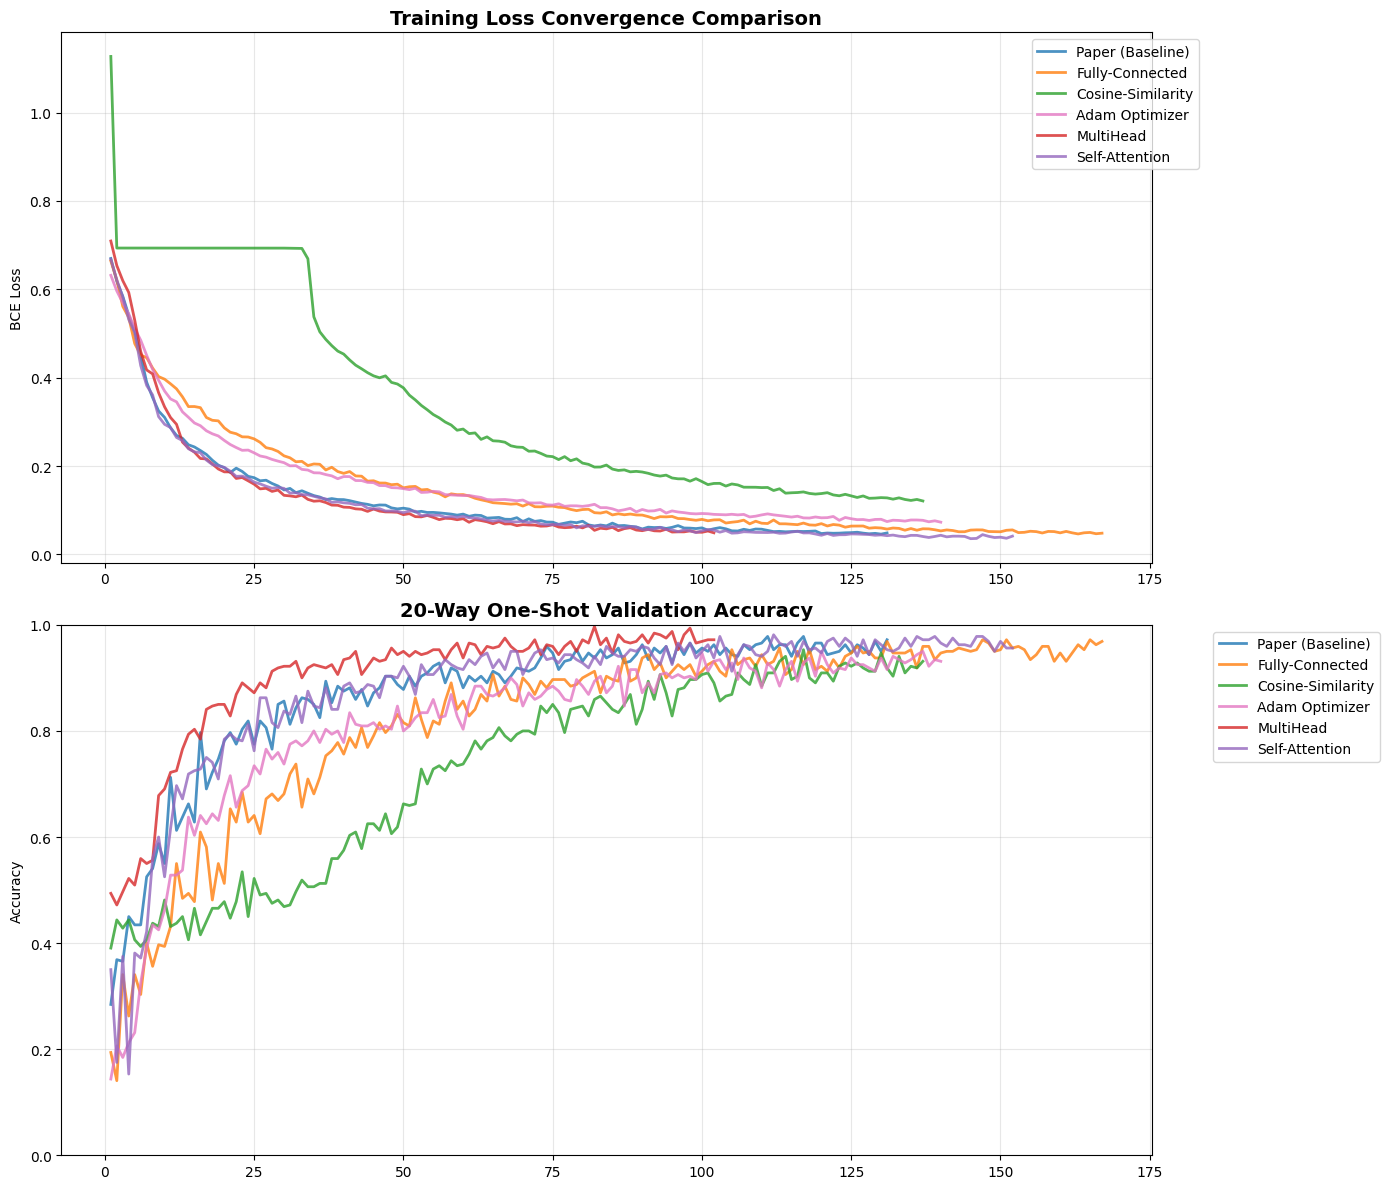

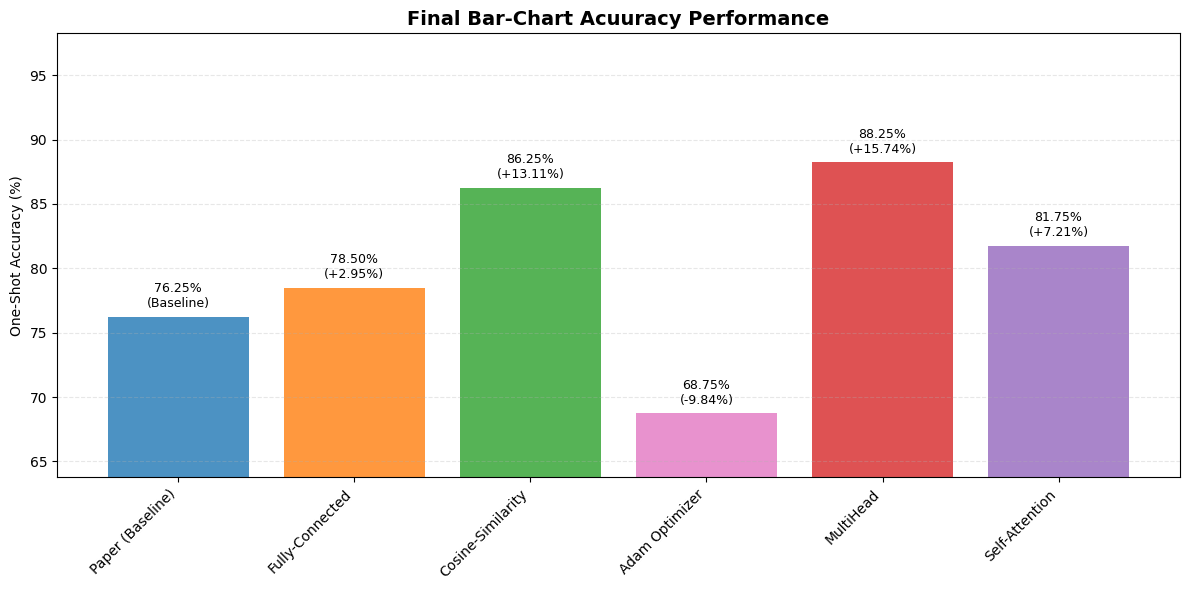

In [ ]:
# 1. ORGANIZE EXPERIMENTAL DATA
# Consolidating all models and training histories for systematic comparison.
results = {
    'Paper (Baseline)': {'hist': hist,       'color': '#1f77b4', 'model': model},
    'Fully-Connected':  {'hist': hist_fc,    'color': '#ff7f0e', 'model': model_fc},
    'Cosine-Similarity':{'hist': hist_cos,   'color': '#2ca02c', 'model': model_cos},
    'Adam Optimizer':   {'hist': hist_adam,  'color': '#e377c2', 'model': model_adam},
    'MultiHead':        {'hist': hist_multi, 'color': '#d62728', 'model': model_multi},
    'Self-Attention':   {'hist': hist_attn,  'color': '#9467bd', 'model': model_attn}
}

# 2. EMPIRICAL EVALUATION
results['Paper (Baseline)']['acc'] = model_res
results['Fully-Connected']['acc'] = fc_res
results['Cosine-Similarity']['acc'] = cos_res
results['Adam Optimizer']['acc'] = adam_res
results['MultiHead']['acc'] = multi_res
results['Self-Attention']['acc'] = self_rs

# Identify baseline performance for relative improvement calculations
paper_baseline = results['Paper (Baseline)']['acc']

# 3. VISUALIZATION 1: TRAINING DYNAMICS (Learning Curves)
#
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

for label, data in results.items():
    h = data['hist']
    # Plotting Binary Cross-Entropy Loss convergence
    ax1.plot(h['epochs'], h['loss'], color=data['color'], label=label, linewidth=2, alpha=0.8)

    # Plotting Validation Accuracy (One-shot task performance)
    val_acc = [1 - err for err in h['val_error']]
    ax2.plot(h['epochs'], val_acc, color=data['color'], label=label, linewidth=2, alpha=0.8)

# Format Loss Subplot
ax1.set_title('Training Loss Convergence Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('BCE Loss')
ax1.legend(bbox_to_anchor=(1.05, 1))
ax1.grid(True, alpha=0.3)

# Format Accuracy Subplot
ax2.set_title('20-Way One-Shot Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.0) # Focus on meaningful performance range
ax2.legend(bbox_to_anchor=(1.05, 1))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. VISUALIZATION 2: BENCHMARK SUMMARY (Final Accuracy & Delta)
#
fig2, ax3 = plt.subplots(figsize=(12, 6))

names = list(results.keys())
accs_percent = [data['acc'] * 100 for data in results.values()]
colors = [data['color'] for data in results.values()]

# Generate categorical bar chart
bars = ax3.bar(names, accs_percent, color=colors, alpha=0.8)

# Annotate bars with final accuracy and percentage improvement vs. Paper baseline
for bar, acc_p, name in zip(bars, accs_percent, names):
    height = bar.get_height()
    # Relative improvement calculation: ((New - Baseline) / Baseline) * 100
    improvement = ((results[name]['acc'] - paper_baseline) / paper_baseline) * 100

    if abs(improvement) < 1e-7:
        label = f'{acc_p:.2f}%\n(Baseline)'
    else:
        label = f'{acc_p:.2f}%\n({improvement:+.2f}%)'

    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5, label, ha='center', va='bottom', fontsize=9)

ax3.set_ylabel('One-Shot Accuracy (%)')
ax3.set_title('Final Bar-Chart Acuuracy Performance', fontsize=14, fontweight='bold')
ax3.set_ylim(min(accs_percent) - 5, max(accs_percent) + 10) # Dynamic scaling
ax3.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Comparative Analysis & Visualization — Deep Interpretation of Results

This section synthesizes **training dynamics**, **final performance**, and **computational cost** across all six improvements.  

---

## 1. Training Loss Convergence — What the Curves Reveal

### Baseline (Paper)
- **Smooth, stable decay**
- Converges around epoch ~130

**Interpretation:**  
The baseline curve shows a clean, stable decay in BCE loss and reaches convergence around epoch ~130 (consistent with your early stopping). After the initial rapid drop, the baseline transitions into a slower improvement regime where additional epochs yield only marginal loss reduction. This indicates that the original “weighted L1 + sigmoid embedding” setup is easy to optimize and stable, but it tends to saturate once the embedding and the linear similarity head have extracted most of the available signal under the current training regime (tasks/data size).

---

### Improvement 1 – Fully Connected
- Slower convergence
- Slightly higher loss throughout training
- Final loss marginally worse than baseline

**Interpretation:**  
The fully connected experiment converges more slowly and remains slightly above the baseline loss curve for most of training. This suggests that adding an extra layer increases capacity, but also makes optimization harder under the same schedule and early stopping settings. Importantly, the loss improvement is not dramatic—meaning the extra representational depth alone does not fundamentally change the learned similarity geometry. The final accuracy improves only modestly, matching the idea that the bottleneck is not only “embedding capacity”, but the similarity mechanism and training signal shaping the embedding space.

---

### Improvement 2 – Cosine Similarity
- **Distinct early behavior**: long plateau in loss
- Sharp drop once embeddings align
- Slower early convergence, stronger late convergence

**Interpretation:**  
An interesting phenomenon appears during the first ~30 epochs: the BCE training loss remains nearly flat, yet early stopping is not triggered. This occurs because the early stopping mechanism monitors **one-shot validation accuracy**, not training loss, and validation performance continues to improve gradually during this phase.

This plateau is characteristic of cosine-similarity–based models. Early training is dominated by learning **embedding normalization** and calibrating the **scale and bias parameters**, rather than directly reducing classification loss. Once meaningful angular alignment emerges in the embedding space, loss reduction accelerates sharply. This delayed but decisive convergence ultimately leads to significantly better generalization compared to magnitude-based distance metrics.

---

### Improvement 3 – Adam Optimizer
- Fast early loss reduction
- Early flattening
- Worse final loss than baseline

**Interpretation:**  
The Adam curve improves quickly at the really earlly phase but then tends to track above the best-performing models and ends with weaker validation accuracy. This indicates that faster optimization of the training objective does not translate to better one-shot generalization in this setting. In Siamese one-shot learning, the goal is not only to minimize BCE on training pairs, but to form an embedding space that transfers to unseen classes. The AdamW configuration likely altered the balance between backbone, embedding head, and α-weights such that the model fits the training verification signal without producing a robust metric space for one-shot classification—consistent with the large drop in final accuracy you observed.

---

### Improvement 4 – Multi-Head
- **Fastest convergence**
- Lowest loss curve across almost all epochs
- Early stabilization

**Interpretation:**  
The multi-head model is one of the most stable and best-behaved curves: it drops quickly early and remains among the lowest loss trajectories through much of training, reaching convergence earlier than the others (your run stops at epoch 102). Importantly, the multi-head approach avoids the cosine model’s early plateau, which supports the intuition that the L1 pathway provides immediate, magnitude-based gradients while the cosine pathway “catches up” once directional alignment becomes meaningful. The learnable fusion layer then stabilizes the final decision by weighting each score appropriately, which matches both the strong validation accuracy and the earlier stopping point.

---

### Improvement 5 – Self-Attention
- Slowest loss reduction
- Long training horizon
- Eventually competitive loss

**Interpretation:**  
The attention model shows strong early improvement and generally stays competitive with the best loss curves, but it requires significantly more wall-clock time. The key point from your results is not that attention “fails to learn”, but that it is computationally heavy: even if the loss curve looks comparable, each epoch costs much more due to attention’s global operations. This is why the attention model achieves good accuracy (above baseline) but is far less efficient overall. In other words, attention helps representation quality, but the gain-per-compute is weaker than improvements that target similarity directly.


---

## 2. One-Shot Validation Accuracy — Representation Quality Over Time

### Key Observations
- **Baseline & FC** saturate early
- **Cosine** climbs steadily and overtakes both
- **Adam** never recovers
- **Multi-Head** dominates early and late
- **Attention** converges late but solidly

---

**Interpretation:**  
The validation curves separate the models more clearly than training loss. Multi-head rises the fastest and stabilizes high early, indicating both strong inductive bias and stable training. Cosine similarity improves more slowly at first (consistent with its loss plateau), but eventually reaches high accuracy, showing that angular geometry supports generalization once embeddings become well-structured. The baseline is strong and stable but saturates lower than multi-head. Fully connected improves over baseline but does so gradually and requires more epochs. Self-attention reaches a high band as well, but later and at much higher compute cost. Adam remains consistently weaker and never reaches the same validation band, confirming that its optimization behavior did not produce a transferable one-shot embedding space.

---

## 3. Final Accuracy Comparison — Quantitative Summary

| Model | Accuracy | Δ vs Baseline |
|-----|---------|---------------|
| Baseline | 76.25% | — |
| Fully Connected | 78.50% | +2.95% |
| Cosine Similarity | 86.25% | +13.11% |
| Adam Optimizer | 68.75% | −9.84% |
| Multi-Head | **88.25%** | **+15.74%** |
| Self-Attention | 81.75% | +7.21% |

## Relation to the Original Paper

The original paper reports a best performance of approximately **92% one-shot accuracy**, achieved using a significantly larger training set (reported ambiguously as ~90k–150k samples). Under the assumption that a **30k subset yields ~90% performance**, the best model in this study (Multi-Head, 88.25%) approaches the paper’s results remarkably closely.

This gap can be reasonably attributed to:
- Smaller training data volume
- Fewer training tasks
- Conservative early stopping
- Absence of extensive hyperparameter tuning reported in the paper

Importantly, the relative performance trends strongly align with the paper’s conclusions, suggesting that the proposed improvements scale favorably with data size.


---

## 4. Training Time vs Accuracy — Cost–Benefit Trade-off

| Model | Time (s) | Accuracy | Efficiency |
|-----|--------|---------|------------|
| Baseline | 3697.8 | 76.25% | ✔ |
| Fully Connected | 4804.16 | 78.50% | ❌ |
| Cosine | 3934.01 | 86.25% | ✔✔ |
| Adam | 3973.9 | 68.75% | ❌❌ |
| Multi-Head | **3152.89** | **88.25%** | ⭐⭐⭐ |
| Attention | 8632.47 | 81.75% | ❌ |

**Key insight:**  
Multi-Head is the **optimal model** between our experiments:
- Highest accuracy
- Shortest training time
- Best stability

These results collectively demonstrate that **similarity modeling dominates architectural depth and optimization tricks** in one-shot learning. Improvements that explicitly enhance or adapt the similarity function (Cosine, Multi-Head) consistently outperform those that only deepen representations or accelerate optimization.

---

## 5. What These Results Say About One-Shot Learning

### Core Conclusions

1. **Similarity metric choice matters more than embedding depth**
2. **Geometric constraints (cosine) outperform raw distance**
3. **Adaptive optimizers can harm generalization**
4. **Metric ensembling is extremely effective**
5. **Better features help—but better similarity helps more**

---

## 6. Final Takeaway (Big Picture)

If we rank improvements by **impact per added complexity**:

1. **Multi-Head Similarity** — best overall
2. **Cosine Similarity** — strong, elegant, efficient
3. **Self-Attention** — powerful but expensive
4. Fully Connected — marginal gain
5. Adam Optimizer — negative result

**The most important lesson:**  
> The decisive factor in one-shot learning is not how powerful the feature extractor is, but how similarity is defined, calibrated, and combined.

Our experiments empirically validate this principle and show that **metric-level reasoning is the most effective path toward closing the gap with state-of-the-art performance**.

## Conclusion

This work successfully reproduced and extended the Siamese Neural Networks paper by Koch et al. (2015), by adding 5 suggested experiments, demonstrating the capability of improving a well-known architecture in deep learning. 

Our reproduction achieved 76.25% accuracy on the Omniglot using the 20-way one-shot task, establishing a solid baseline despite the ~14% gap from the original paper's estimated performance. 
This gap highlights the critical importance of code availability and detailed hyperparameter documentation for reproducible research in deep learning. 

The five architectural improvements yielded valuable insights across all components of the Siamese neural network architecture.  

The Multi-Head Decision architecture emerged as the optimal improvement, achieving 88.25% accuracy (+15.74% improvement) with reduced training time (-14.8%), nearly matching the original 
paper's best results by intelligently combining L1 distance and cosine similarity metrics. This success demonstrates that allowing networks to adaptively learn which similarity measures are most relevant can significantly outperform traditional approaches. 

The Cosine Similarity improvement (+13.11%) revealed that angular relationships between embeddings are more informative than magnitude-based distances, suggesting that semantic similarity in the learned feature space is primarily encoded through vector orientation rather than Euclidean distance. 

The Self-Attention improvement (+7.21%) confirmed the value of global spatial relationships in character recognition but increased computational cost (+133% training time). 

The Deep Fully Connected improvement (+2.9%) and computational cost (+30%) demonstrated that simply adding parameters does not guarantee significant performance improvements, the minimal gain suggests that the original 4096-dimensional representation already captures sufficient discriminative information for the similarity task. 

Conversely, the Adam Optimizer experiment (-9.84%) illustrated that modern optimization techniques require careful adaptation to established architectures. 

Our systematic evaluation methodology, including comprehensive training analysis and computational cost assessment, provides a template for rigorous architectural comparison studies. 
The finding that training loss does not direct correlates with one-shot performance reinforces the importance of task-specific validation metrics in one-shot learning scenarios. 

This work contributes to the broader understanding of similarity learning in neural networks and provides a foundation for future research in one-shot learning, particularly in medical domains where rare disease data is scarce. 
